# **Statistical Tools for Data Scientists**
This notebook demonstrates practical statistical tools used in real data science workflows.

In [25]:
# !pip install scipy
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

## **Binomial Distribution**

A binomial distribution is used when:
- There are fixed number of trials
- Each trial has two outcomes
- Each trial has same probability of success
- Trials are independent
  
<center><img src='https://raw.githubusercontent.com/ha2285/img/a76812bf779406dd2a7bcd5a36de294c40c6fc69/bionomial.png' width=400 height=400></center>



### **Example**
**Email marketing conversions**

A company sends marketing emails to customers.
Each email can result in two outcomes:
- Customer converts (clicks + buys)
- Customer does not convert

This is a Bernoulli trial.
If we send multiple emails, the number of conversions follows a Binomial distribution.

Suppose:
- Conversion probability = 0.2 (20%)
- Emails sent = 10000
We want to know:
- Expected conversions
- Probability of 2000 conversions
- Simulated outcomes

In [26]:
n_trials = 10000
probability = 0.2
binom_dist = stats.binom(n_trials, probability)

In [27]:
# simulate conversions
# This simulates running the same marketing campaign multiple times.
simulated_data=binom_dist.rvs(size=10000)   # Each number represents how many customers converted in one marketing campaign.

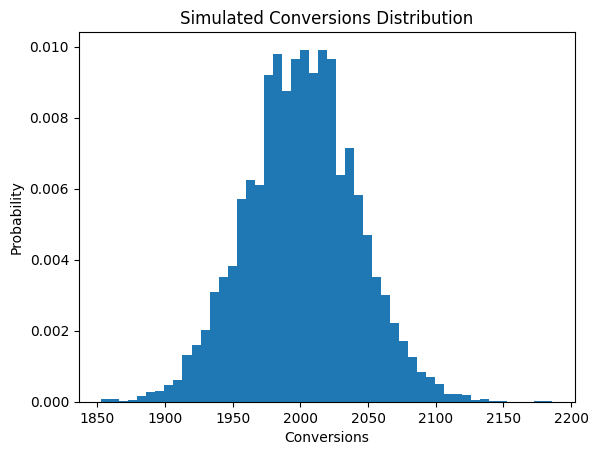

In [28]:
# Plot simulation histogram
plt.hist(simulated_data, bins=50, density=True)
plt.xlabel('Conversions')
plt.ylabel('Probability')
plt.title('Simulated Conversions Distribution');

In [29]:
# Probability of exactly 2000 conversions
binom_dist.pmf(2000) # If we run one campaign, what is the probability that exactly 2000 customers convert out of 10000 emails?
print(binom_dist.pmf(2000))

0.009973120676464478


In [30]:
# What’s the risk that nobody buys anything in this campaign?
binom_dist.pmf(0)

np.float64(0.0)

In [31]:
# Probability that 2000 or fewer customers convert (click + buy) in this campaign.
answer=binom_dist.cdf(2000)
print(f"{answer:.5f}")

0.50598


## **Normal Distribution**

Most performance metrics follow a Normal distribution.

Examples:

- website response time
- delivery time
- product weight
- measurement errors

<center><img src='https://raw.githubusercontent.com/ha2285/img/1871b947f363f6bad8d8ca955597f7819745bf4d/normal.png' width=500 height=500></center>

### **Example**

A company measures website page load time.

Example values:

```
1.8 seconds
2.1 seconds
1.9 seconds
2.4 seconds
1.7 seconds 
```

- Average load time = 2 seconds
- with Small variation due to:
    - network
    - server load
    - user device

In [32]:
# Example: website response time
mean = 2
variance = 0.5
normal_dist = stats.norm(mean, variance)

In [33]:
# This generates 1000 simulated page loads.
load_times = normal_dist.rvs(size=1000) 

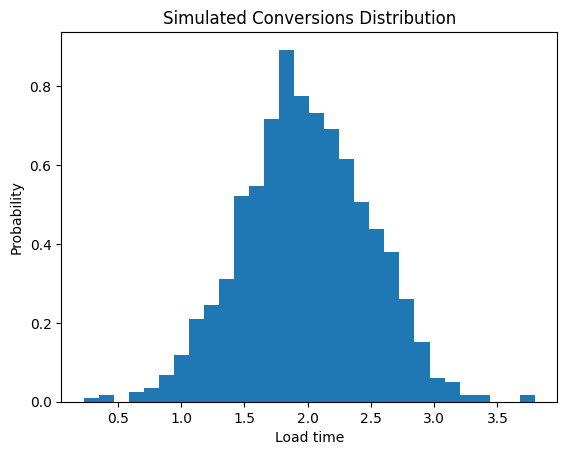

In [34]:
# Plot simulation histogram
plt.hist(load_times, bins=30, density=True);
plt.xlabel('Load time')
plt.ylabel('Probability')
plt.title('Simulated Conversions Distribution');

In [35]:
# probability density
normal_dist.pdf(2)   # the likelihood density around 2 seconds (results show that 2 seconds is a very common page load time)

np.float64(0.7978845608028654)

In [36]:
# probability density
normal_dist.pdf(2)   # the likelihood density around 2 seconds (results show that 2 seconds is a very common page load time)
# cumulative probability
# Probability load time ≤ 2 seconds
normal_dist.cdf(2)   # What fraction of users experience load time ≤ 2 seconds?

np.float64(0.5)

## **Distribution Diagnostics**

In [37]:
# Normality test
# Tests the null hypothesis (H0) that a sample comes from a normal distribution.
# If the p-value < alpha, we reject H0, indicating the sample likely does NOT come from a normal distribution.

stats.normaltest(load_times)

NormaltestResult(statistic=np.float64(0.48672747607877653), pvalue=np.float64(0.7839862962641622))

#### **Skewness Test**

In [38]:
# Null hypothesis (H0): The data is symmetric (skew = 0)
#  p < alpha (e.g., 0.05)   → reject H0          → data is significantly skewed
#  p >= alpha               → fail to reject H0  → data is not significantly skewed
stats.skewtest(load_times)

SkewtestResult(statistic=np.float64(-0.16406883498661073), pvalue=np.float64(0.8696769553957832))

#### **kurtosis Test**

In [39]:
# Null hypothesis (H0): The data has normal kurtosis (i.e., kurtosis = 3)
#  p < alpha (e.g., 0.05)   → reject H0          → data has significantly non-normal kurtosis (heavy tails or light tails)
#  p >= alpha               → fail to reject H0  → data does not significantly deviate from normal kurtosis
stats.kurtosistest(load_times)

KurtosistestResult(statistic=np.float64(0.6780920980699545), pvalue=np.float64(0.49771330060194063))

## **One Sample t-test**

- Tests whether the mean of a sample is equal to a known value (population mean μ0)
    - Null hypothesis (H0):  sample mean = popmean
    - Alternative hypothesis (H1): sample mean ≠ popmean
- Interpretation:
    - If p < alpha (e.g., 0.05) → reject H0 → sample mean is significantly different from popmean
    - If p >= alpha → fail to reject H0 → no significant difference from popmean

In [40]:
# H0: mean load time = 2 seconds
stats.ttest_1samp(load_times, 2)

TtestResult(statistic=np.float64(-0.9245837469047297), pvalue=np.float64(0.35540574484776555), df=np.int64(999))

---
## **Independent Two Sample t-test**

- Tests whether the means of two independent samples are equal
    - Null hypothesis (H0): the two samples have equal means
    - Alternative hypothesis (H1): the two samples have different means
- Interpretation:
    - If p < alpha (e.g., 0.05) → reject H0 → means are significantly different
    - If p >= alpha → fail to reject H0 → no significant difference between means

In [41]:
version_A = stats.norm(2,0.5).rvs(size=100)
version_B = stats.norm(2.2,0.5).rvs(size=100)

stats.ttest_ind(version_A, version_B)

TtestResult(statistic=np.float64(-3.115318760797158), pvalue=np.float64(0.002110280874745017), df=np.float64(198.0))

In [42]:
# Example - Sanity Check via Resampling
sub_sample1 = np.random.choice(load_times, size=20, replace=True)
sub_sample2 = np.random.choice(load_times, size=20, replace=True)

stats.ttest_ind(sub_sample1, sub_sample2)

TtestResult(statistic=np.float64(-1.199886291226102), pvalue=np.float64(0.23761114675420653), df=np.float64(38.0))

---
## **One-way ANOVA (Analysis of Variance)**

- Tests whether the means of two or more independent groups are equal
    - Null hypothesis (H0): all group means are equal
    - Alternative hypothesis (H1): at least one group mean is different
- Interpretation:
    - If p < alpha (e.g., 0.05) → reject H0 → at least one group differs significantly
    - If p >= alpha → fail to reject H0 → no significant difference among group means

In [43]:
campaign1 = stats.norm(50,5).rvs(size=50)
campaign2 = stats.norm(55,5).rvs(size=50)
campaign3 = stats.norm(60,5).rvs(size=50)

stats.f_oneway(campaign1, campaign2, campaign3)

F_onewayResult(statistic=np.float64(78.77837598986638), pvalue=np.float64(5.6002709318371536e-24))

#### **Example**
- Compare test scores of students taught using three different teaching methods.
    - H0: All group means are equal
    - H1: At least one mean differs

In [44]:
# Sample data: three groups
group_A = [23, 21, 25, 22]
group_B = [30, 28, 27, 29]
group_C = [20, 19, 21, 22]

stats.f_oneway(group_A, group_B, group_C)

F_onewayResult(statistic=np.float64(32.67999999999995), pvalue=np.float64(7.46558900540892e-05))

---
## **Chi-Square Goodness of Fit**

- Tests whether the observed frequencies match the expected frequencies
    - Null hypothesis (H0): observed frequencies = expected frequencies
    - Alternative hypothesis (H1): observed frequencies ≠ expected frequencies
- Interpretation:
    - If p < alpha (e.g., 0.05) → reject H0 → observed counts significantly differ from expected
    - If p >= alpha → fail to reject H0 → no significant difference

In [45]:
observed = [30,25,20,25]
expected = [25,25,25,25]

stats.chisquare(f_obs=observed, f_exp=expected)

Power_divergenceResult(statistic=np.float64(2.0), pvalue=np.float64(0.5724067044708798))

#### **Example**
- Scenario: A candy company produces M&M’s in 5 colors. They claim each color is equally likely. You buy a bag and count the colors:
| Color    | Red | Blue | Green | Yellow | Orange | Brown |
| -------- | --- | ---- | ----- | ------ | ------ | ----- |
| Observed | 12  | 10   | 8     | 15     | 9      | 6     |

- **Question:** Do the observed counts match the expected uniform distribution?


In [46]:
observed = [12, 10, 8, 15, 9, 6]
stats.chisquare(f_obs=observed)

Power_divergenceResult(statistic=np.float64(5.0), pvalue=np.float64(0.41588018699550783))

---
## **Chi-Square Test of Independence**

- Tests whether two categorical variables are independent
    - Null hypothesis (H0): the variables are independent
    - Alternative hypothesis (H1): the variables are dependent
- Interpretation:
    - If p < alpha (e.g., 0.05) → reject H0 → variables are significantly associated
    - If p >= alpha → fail to reject H0 → no significant association

In [47]:
crosstab = np.array([
 [50,30],
 [40,60]
])

stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=np.float64(8.1225), pvalue=np.float64(0.004371922909826479), dof=1, expected_freq=array([[40., 40.],
       [50., 50.]]))

#### **Example**
- A health researcher wants to know if smoking status is associated with lung disease. They collect data from 200 people:

|            | Lung Disease | No Lung Disease | Total |
| ---------- | ------------ | --------------- | ----- |
| Smoker     | 40           | 60              | 100   |
| Non-Smoker | 10           | 90              | 100   |

**Question:** Are smoking and lung disease independent, or is there a significant association?


In [48]:
# Null hypothesis (H0): Smoking and lung disease are independent.
# Alternative hypothesis (H1): Smoking and lung disease are not independent (associated).

observed = [[40, 60],   # Smokers
            [10, 90]]   # Non-Smokers

stats.chi2_contingency(observed)

Chi2ContingencyResult(statistic=np.float64(22.42666666666667), pvalue=np.float64(2.1832165337148533e-06), dof=1, expected_freq=array([[25., 75.],
       [25., 75.]]))